# EDA – Exploratory Data Analysis

## Environment setup and data loading

Library imports, path configuration and helper functions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/raw/produkcja.csv')

def plot_box_hist(df, flag_col, value_col, palette="Set1"):
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    sns.boxplot(
        x=flag_col,
        y=value_col,
        hue=flag_col,
        data=df,
        palette=palette,
        ax=axes[0],
        legend=False
    )
    axes[0].set_title(f"Box plot {flag_col} vs {value_col}")

    sns.histplot(
        data=df,
        x=value_col,
        hue=flag_col,
        palette=palette,
        ax=axes[1],
        kde=True
    )
    axes[1].set_title(f"Histogram {value_col}")

    plt.tight_layout()
    plt.show()

Feature engineering – creating derived variables

In [2]:
power = (df['Rotational speed [rpm]'] * df['Torque [Nm]'] * (2 * np.pi / 60)).round(2)

df.insert(loc = 8, column = 'Power [W]', value = power)
df.insert(loc = 5, column = 'Temperature difference', value = df['Process temperature [K]'] - df['Air temperature [K]'])

## Dataset profiling – structure and data quality

### Data structure

Preview of the first records

In [3]:
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,10.5,1551,42.8,0,6951.59,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,10.5,1408,46.3,3,6826.72,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,10.4,1498,49.4,5,7749.39,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,10.4,1433,39.5,7,5927.50,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,10.5,1408,40.0,9,5897.82,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,10.5,1425,41.9,11,6252.55,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,10.5,1558,42.4,14,6917.70,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,10.5,1527,40.2,16,6428.26,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,10.4,1667,28.6,18,4992.64,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,10.5,1741,28.0,21,5104.88,0,0,0,0,0,0


Completeness check

In [4]:
df.isnull().any().any()

np.False_

Dataset size

In [5]:
df.shape

(10000, 16)

Data types

In [6]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Temperature difference     float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Power [W]                  float64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Basic descriptive statistics

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,10.000630,1538.776100,39.986910,107.951000,6279.744933,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,1.001094,179.284096,9.968934,63.654147,1067.418312,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,7.600000,1168.000000,3.800000,0.000000,1148.440000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,9.300000,1423.000000,33.200000,53.000000,5561.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,9.800000,1503.000000,40.100000,108.000000,6271.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,11.000000,1612.000000,46.800000,162.000000,7003.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,12.100000,2886.000000,76.600000,253.000000,10469.920000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Duplicate detection

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
display(df['UDI'].is_unique)
display(df['Product ID'].is_unique)

True

True

Type vs Product ID prefix (ID uniqueness)

In [10]:
pd.crosstab(df['Type'], df["Product ID"].str[0])

Product ID,H,L,M
Type,,,
H,1003,0,0
L,0,6000,0
M,0,0,2997


### Data validity checks

#### Edge-case analysis

In [11]:
display(df[df['RNF']== 1].shape[0])
display(df[df['RNF']== 1])

19

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,297.0,308.3,11.3,1399,46.4,132,6797.74,0,0,0,0,0,1
1302,1303,L48482,L,298.6,309.8,11.2,1505,45.7,144,7202.47,0,0,0,0,0,1
1748,1749,H31162,H,298.4,307.7,9.3,1626,31.1,166,5295.53,0,0,0,0,0,1
2072,2073,L49252,L,299.6,309.5,9.9,1570,35.5,189,5836.56,0,0,0,0,0,1
2559,2560,L49739,L,299.3,309.0,9.7,1447,50.4,140,7637.09,0,0,0,0,0,1
3065,3066,M17925,M,300.1,309.2,9.1,1687,27.7,95,4893.54,0,0,0,0,0,1
3452,3453,H32866,H,301.6,310.5,8.9,1602,32.3,2,5418.68,0,0,0,0,0,1
3611,3612,L50791,L,301.7,310.9,9.2,1405,46.4,207,6826.89,1,1,0,0,0,1
5471,5472,L52651,L,302.7,312.3,9.6,1346,61.2,170,8626.31,0,0,0,0,0,1
5489,5490,L52669,L,302.6,312.1,9.5,1499,35.0,215,5494.12,0,0,0,0,0,1


**Observation:**

Records flagged as RNF have no Machine failure assigned.

In [12]:
display(df[((df['TWF'] == 1) | (df['HDF'] == 1) | (df['PWF'] == 1) | (df['OSF'] == 1)| (df['RNF'] == 1)) & (df['Machine failure'] == 0)])
display(df[((df['TWF'] == 1) | (df['HDF'] == 1) | (df['PWF'] == 1) | (df['OSF'] == 1)| (df['RNF'] == 1)) & (df['Machine failure'] == 0)].shape[0])

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,297.0,308.3,11.3,1399,46.4,132,6797.74,0,0,0,0,0,1
1302,1303,L48482,L,298.6,309.8,11.2,1505,45.7,144,7202.47,0,0,0,0,0,1
1748,1749,H31162,H,298.4,307.7,9.3,1626,31.1,166,5295.53,0,0,0,0,0,1
2072,2073,L49252,L,299.6,309.5,9.9,1570,35.5,189,5836.56,0,0,0,0,0,1
2559,2560,L49739,L,299.3,309.0,9.7,1447,50.4,140,7637.09,0,0,0,0,0,1
3065,3066,M17925,M,300.1,309.2,9.1,1687,27.7,95,4893.54,0,0,0,0,0,1
3452,3453,H32866,H,301.6,310.5,8.9,1602,32.3,2,5418.68,0,0,0,0,0,1
5471,5472,L52651,L,302.7,312.3,9.6,1346,61.2,170,8626.31,0,0,0,0,0,1
5489,5490,L52669,L,302.6,312.1,9.5,1499,35.0,215,5494.12,0,0,0,0,0,1
5495,5496,H34909,H,302.9,312.5,9.6,1357,55.0,12,7815.76,0,0,0,0,0,1


18

**Observation:**

There are 18 such records.

##### Parameter analysis for RNF

Comparison of basic descriptive statistics

In [13]:
display(df[((df['TWF'] == 1) | (df['HDF'] == 1) | (df['PWF'] == 1) | (df['OSF'] == 1)| (df['RNF'] == 1)) & (df['Machine failure'] == 0)].describe())

,UDI,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.0,18.0,18.0,18.0,18.0,18.0
mean,4661.833333,300.766667,310.755556,9.988889,1489.444444,43.522222,119.888889,6677.857222,0.0,0.0,0.0,0.0,0.0,1.0
std,2195.173134,1.743222,1.501459,0.832352,110.833326,10.861294,68.548728,1237.108637,0.0,0.0,0.0,0.0,0.0,0.0
min,1222.000000,297.000000,307.700000,8.900000,1306.000000,27.700000,2.000000,4893.540000,0.0,0.0,0.0,0.0,0.0,1.0
25%,2686.500000,299.725000,309.575000,9.425000,1412.250000,35.125000,61.750000,5562.542500,0.0,0.0,0.0,0.0,0.0,1.0
50%,5493.000000,300.750000,311.100000,9.650000,1490.000000,44.600000,142.000000,6915.075000,0.0,0.0,0.0,0.0,0.0,1.0
75%,5979.000000,302.575000,312.050000,10.375000,1563.750000,51.600000,171.500000,7680.065000,0.0,0.0,0.0,0.0,0.0,1.0
max,7869.000000,302.900000,312.500000,11.500000,1687.000000,61.200000,215.000000,8626.310000,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,10.000630,1538.776100,39.986910,107.951000,6279.744933,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,1.001094,179.284096,9.968934,63.654147,1067.418312,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,7.600000,1168.000000,3.800000,0.000000,1148.440000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,9.300000,1423.000000,33.200000,53.000000,5561.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,9.800000,1503.000000,40.100000,108.000000,6271.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,11.000000,1612.000000,46.800000,162.000000,7003.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,12.100000,2886.000000,76.600000,253.000000,10469.920000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Detecting failures with no failure subtype assigned

In [15]:
display(df[((df['TWF'] == 0) & (df['HDF'] == 0) & (df['PWF'] == 0) & (df['OSF'] == 0) & (df['RNF'] == 0)) & (df['Machine failure'] == 1)])
display(df[((df['TWF'] == 0) & (df['HDF'] == 0) & (df['PWF'] == 0) & (df['OSF'] == 0) & (df['RNF'] == 0)) & (df['Machine failure'] == 1)].shape[0])

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
1437,1438,H30851,H,298.8,309.9,11.1,1439,45.2,40,6811.27,1,0,0,0,0,0
2749,2750,M17609,M,299.7,309.2,9.5,1685,28.9,179,5099.49,1,0,0,0,0,0
4044,4045,M18904,M,301.9,310.9,9.0,1419,47.7,20,7088.09,1,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,8.2,1421,44.8,101,6666.54,1,0,0,0,0,0
5536,5537,M20396,M,302.3,311.8,9.5,1363,54.0,119,7707.58,1,0,0,0,0,0
5941,5942,L53121,L,300.6,310.7,10.1,1438,48.5,78,7303.47,1,0,0,0,0,0
6478,6479,L53658,L,300.5,309.8,9.3,1663,29.1,145,5067.73,1,0,0,0,0,0
8506,8507,L55686,L,298.4,309.6,11.2,1710,27.3,163,4888.63,1,0,0,0,0,0
9015,9016,L56195,L,297.2,308.1,10.9,1431,49.7,210,7447.74,1,0,0,0,0,0


9

##### Parameter analysis for Machine failure with no failure type

Comparison of basic descriptive statistics

In [16]:
anomalies = (df['TWF'] == 0) & (df['HDF'] == 0) & (df['PWF'] == 0) & (df['OSF'] == 0) & (df['RNF'] == 0) & (df['Machine failure'] == 1)
anomalies_df = df[anomalies]
anomalies_df.describe()

,UDI,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.0,9.0,9.0,9.0,9.0,9.0
mean,5377.666667,300.333333,310.200000,9.866667,1507.666667,41.688889,117.222222,6453.393333,1.0,0.0,0.0,0.0,0.0,0.0
std,2481.642198,2.043282,1.218606,1.033199,136.135043,10.303815,63.749074,1121.510605,0.0,0.0,0.0,0.0,0.0,0.0
min,1438.000000,297.200000,308.100000,8.200000,1363.000000,27.300000,20.000000,4888.630000,1.0,0.0,0.0,0.0,0.0,0.0
25%,4045.000000,298.800000,309.600000,9.300000,1421.000000,29.100000,78.000000,5099.490000,1.0,0.0,0.0,0.0,0.0,0.0
50%,5537.000000,300.500000,309.900000,9.500000,1438.000000,45.200000,119.000000,6811.270000,1.0,0.0,0.0,0.0,0.0,0.0
75%,6479.000000,301.900000,310.900000,10.900000,1663.000000,48.500000,163.000000,7303.470000,1.0,0.0,0.0,0.0,0.0,0.0
max,9016.000000,303.600000,311.800000,11.200000,1710.000000,54.000000,210.000000,7707.580000,1.0,0.0,0.0,0.0,0.0,0.0


In [17]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,10.000630,1538.776100,39.986910,107.951000,6279.744933,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,1.001094,179.284096,9.968934,63.654147,1067.418312,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,7.600000,1168.000000,3.800000,0.000000,1148.440000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,9.300000,1423.000000,33.200000,53.000000,5561.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,9.800000,1503.000000,40.100000,108.000000,6271.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,11.000000,1612.000000,46.800000,162.000000,7003.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,12.100000,2886.000000,76.600000,253.000000,10469.920000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


**Observation:**

Comparing the basic descriptive statistics for the 9 anomalous records shows that their mean parameters lie within the normal range. The absence of extreme values suggests these failures may be the result of random label noise rather than a sudden physical component breakdown.

---

Failure analysis at zero tool wear

In [18]:
df[(df['Tool wear [min]' ] == 0) & (df['Machine failure'] == 1)]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
5490,5491,L52670,L,302.6,312.1,9.5,1288,68.5,0,9239.21,1,0,0,1,0,0
6678,6679,M21538,M,301.5,310.7,9.2,1336,65.6,0,9177.81,1,0,0,1,0,0
9175,9176,L56355,L,297.8,309.0,11.2,1403,64.2,0,9432.38,1,0,0,1,0,0


## Relationship between parameters and failure

Histograms for all numeric columns

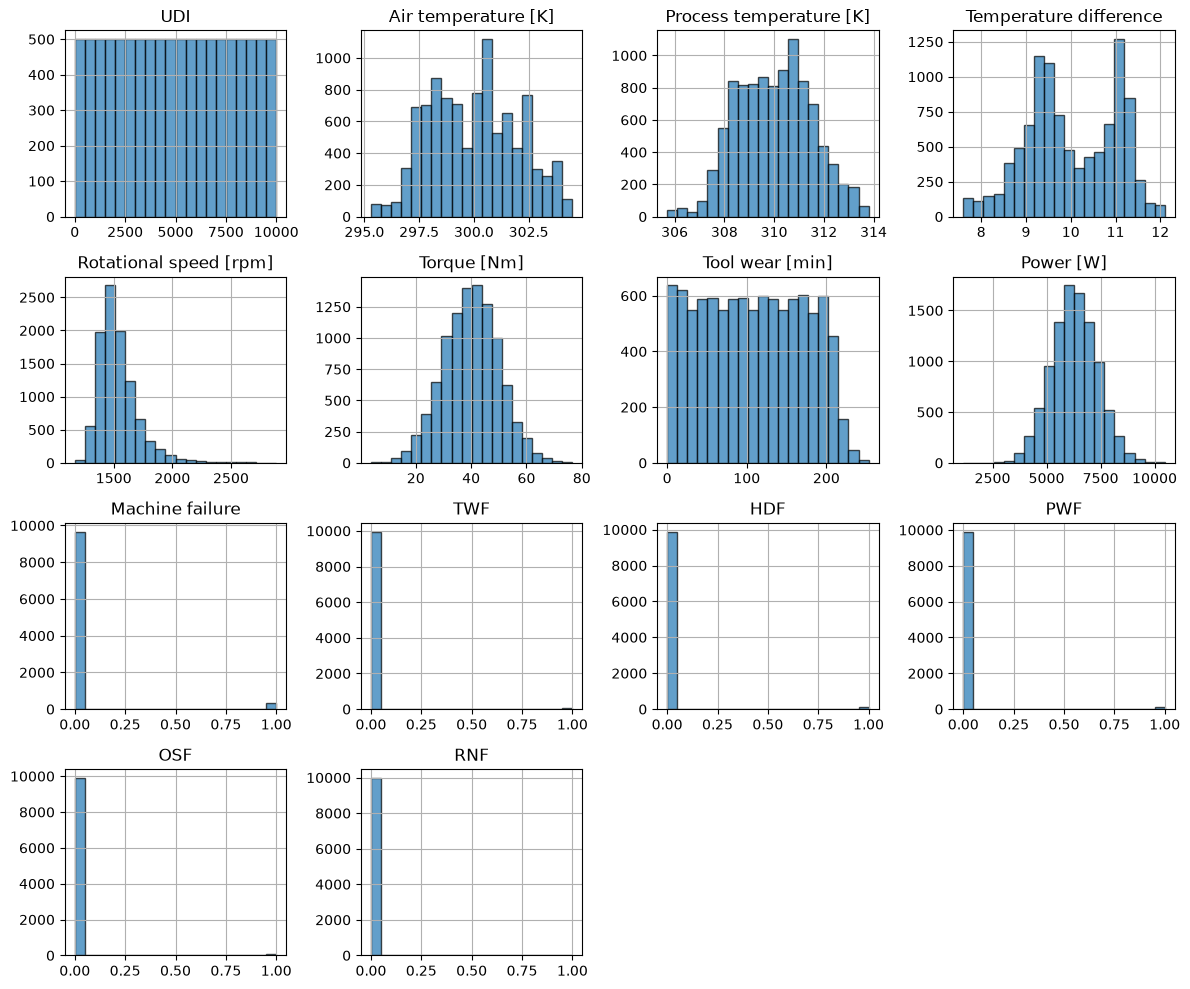

In [19]:
df.hist(figsize=(12, 10), bins=20, edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

### Failure structure by machine type (L, M, H)

Machine counts by type

In [20]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Total number of failures

In [21]:
df[df["Machine failure"] == 1].shape[0]

339

Failure share (percentage)

In [22]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Failure counts by machine type

In [23]:
df[df['Machine failure'] == 1]['Type'].value_counts()

Type
L    235
M     83
H     21
Name: count, dtype: int64

Failure rate by machine type

In [24]:
crosstab = pd.crosstab(df["Type"], df['Machine failure'])

failure_rate = pd.crosstab(df["Type"], df["Machine failure"], normalize ="index") * 100

display(crosstab)
display(failure_rate.round(2))

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


Machine failure,0,1
Type,,
H,97.91,2.09
L,96.08,3.92
M,97.23,2.77


Machine type vs failure cause – summary

In [25]:
failure_columns = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df.groupby('Type')[failure_columns].sum()

,Machine failure,TWF,HDF,PWF,OSF,RNF
Type,,,,,,
H,21,7,8,5,2,4
L,235,25,76,59,87,13
M,83,14,31,31,9,2


Records with more than one failure cause

In [26]:
print(f"Number of records: {df[df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum(axis=1) >= 2].shape[0]}")
display(df[df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1) >= 2])
display(df[df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1) >= 3])

Number of records: 24


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
69,70,L47249,L,298.9,309.0,10.1,1410,65.7,191,9700.92,1,0,0,1,1,0
1324,1325,M16184,M,298.8,310.1,11.3,1243,74.5,194,9697.42,1,0,0,1,1,0
1496,1497,L48676,L,298.0,308.7,10.7,1268,69.4,189,9215.25,1,0,0,1,1,0
3611,3612,L50791,L,301.7,310.9,9.2,1405,46.4,207,6826.89,1,1,0,0,0,1
3854,3855,L51034,L,302.4,311.0,8.6,1338,67.6,194,9471.78,1,0,0,1,1,0
3943,3944,L51123,L,302.3,311.4,9.1,1333,66.7,205,9310.75,1,0,0,1,1,0
4254,4255,L51434,L,302.6,311.0,8.4,1284,68.0,114,9143.29,1,0,1,1,0,0
4342,4343,M19202,M,301.7,309.8,8.1,1284,68.2,111,9170.18,1,0,1,1,0,0
4370,4371,L51550,L,302.0,309.9,7.9,1308,57.6,197,7889.67,1,0,1,0,1,0
4383,4384,L51563,L,301.7,309.5,7.8,1298,65.5,229,8903.17,1,0,1,0,1,0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Temperature difference,Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Machine failure,TWF,HDF,PWF,OSF,RNF
5909,5910,H35323,H,300.7,310.2,9.5,1364,65.3,208,9327.3,1,1,0,1,1,0


Correlation matrix of process parameters

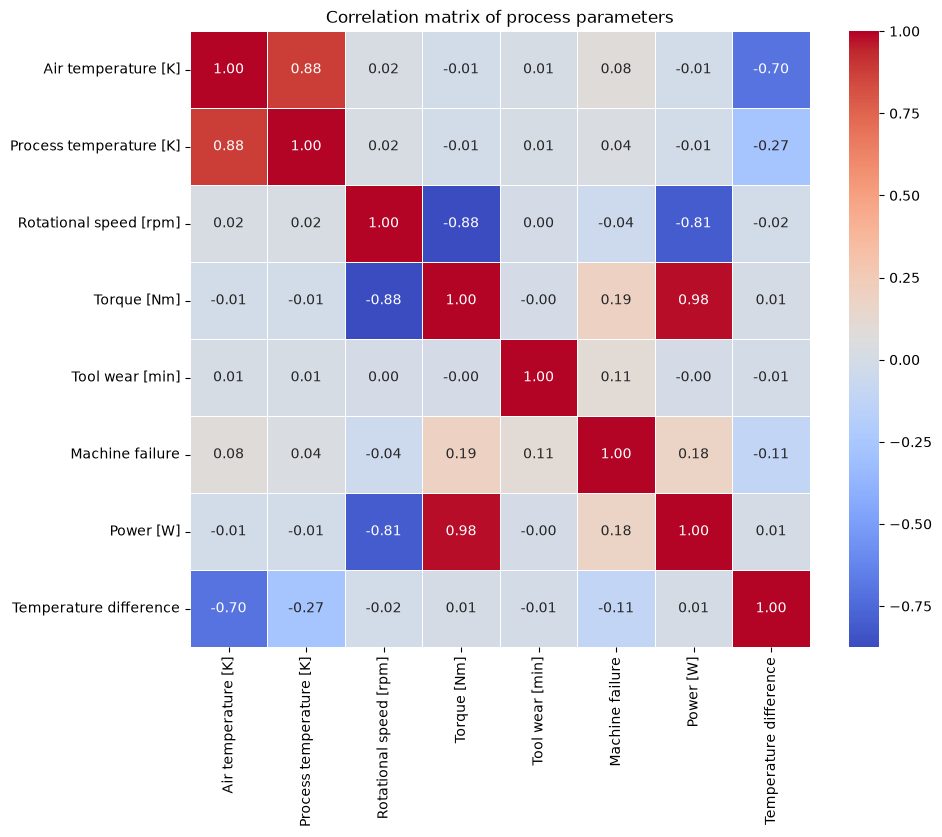

In [27]:
corr_matrix = df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Power [W]','Temperature difference']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix of process parameters")
plt.show()

Scatter plot of Rotational speed vs Torque, colored by Machine failure

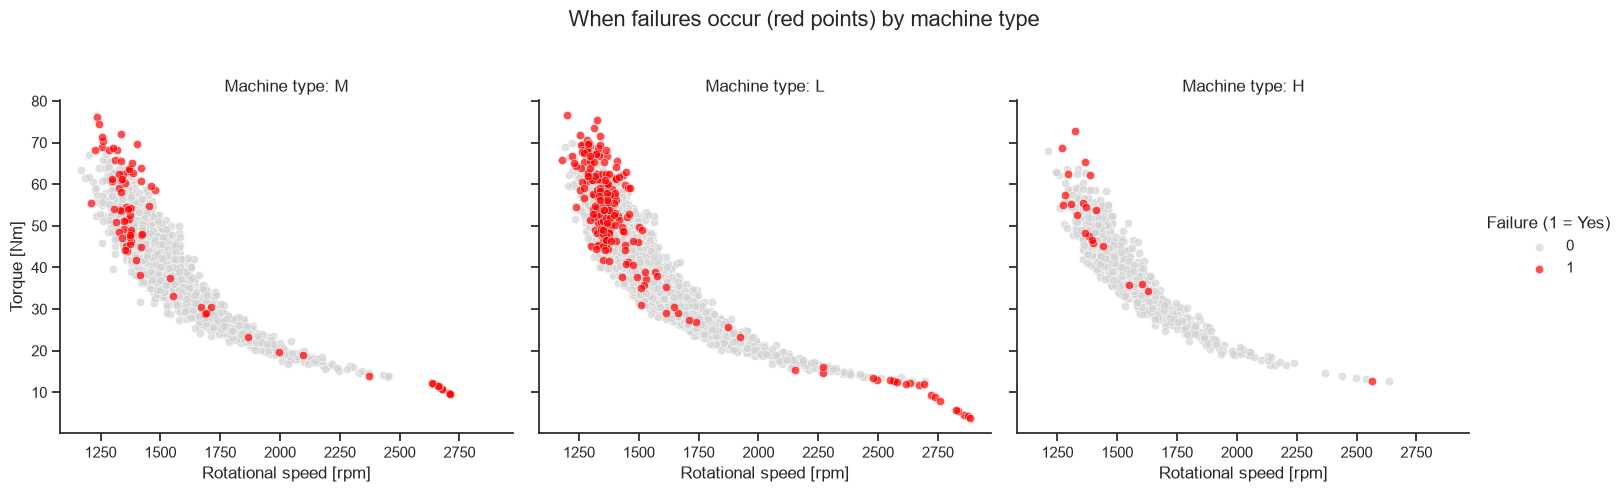

In [28]:
sns.set_theme(style="ticks")

g = sns.FacetGrid(df, col="Type", hue = "Machine failure", palette={0: "lightgray", 1: "red"}, height=5, aspect = 1)

g.map(sns.scatterplot, "Rotational speed [rpm]", "Torque [Nm]", alpha=0.7)

g.add_legend(title="Failure (1 = Yes)")
g.set_titles("Machine type: {col_name}")
plt.subplots_adjust(top=0.8)
g.fig.suptitle('When failures occur (red points) by machine type', fontsize=16)

plt.show()

#### TWF analysis

Relationship between Tool wear and TWF

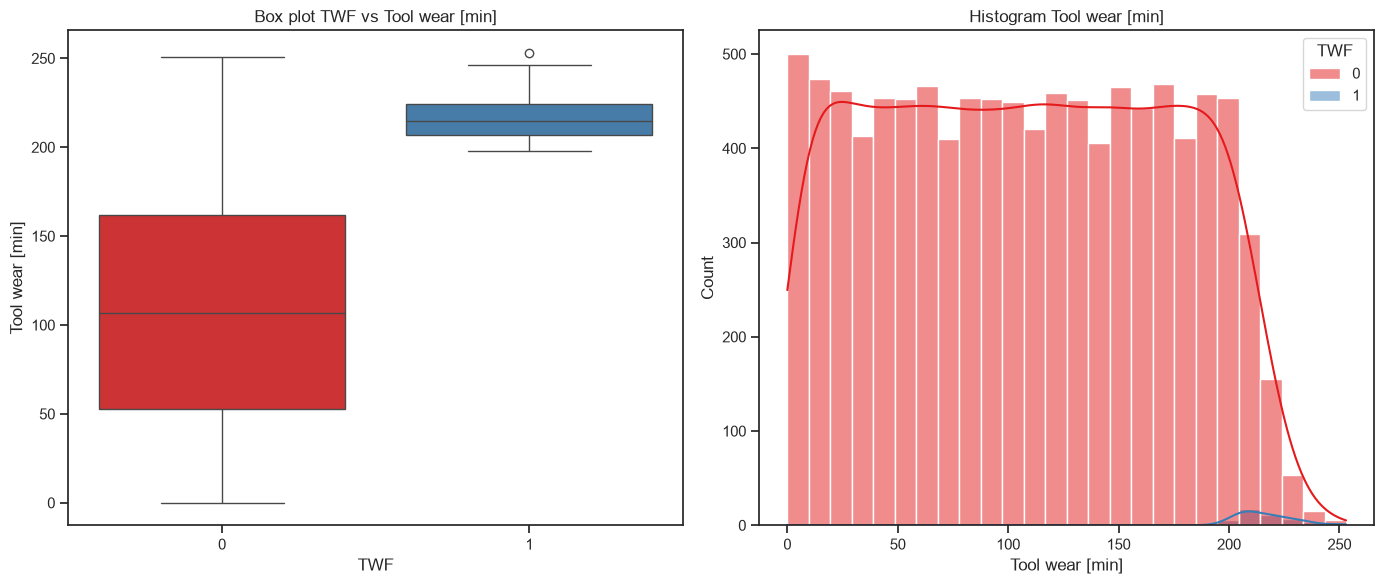

In [29]:
plot_box_hist(df, 'TWF', 'Tool wear [min]')

In [30]:
print(f"Lower bound: {df[df['TWF']==1]['Tool wear [min]'].agg('min')}")
print(f"Upper bound: {df[df['TWF']==1]['Tool wear [min]'].agg('max')}")

Lower bound: 198
Upper bound: 253


Relationship between Rotational speed and TWF

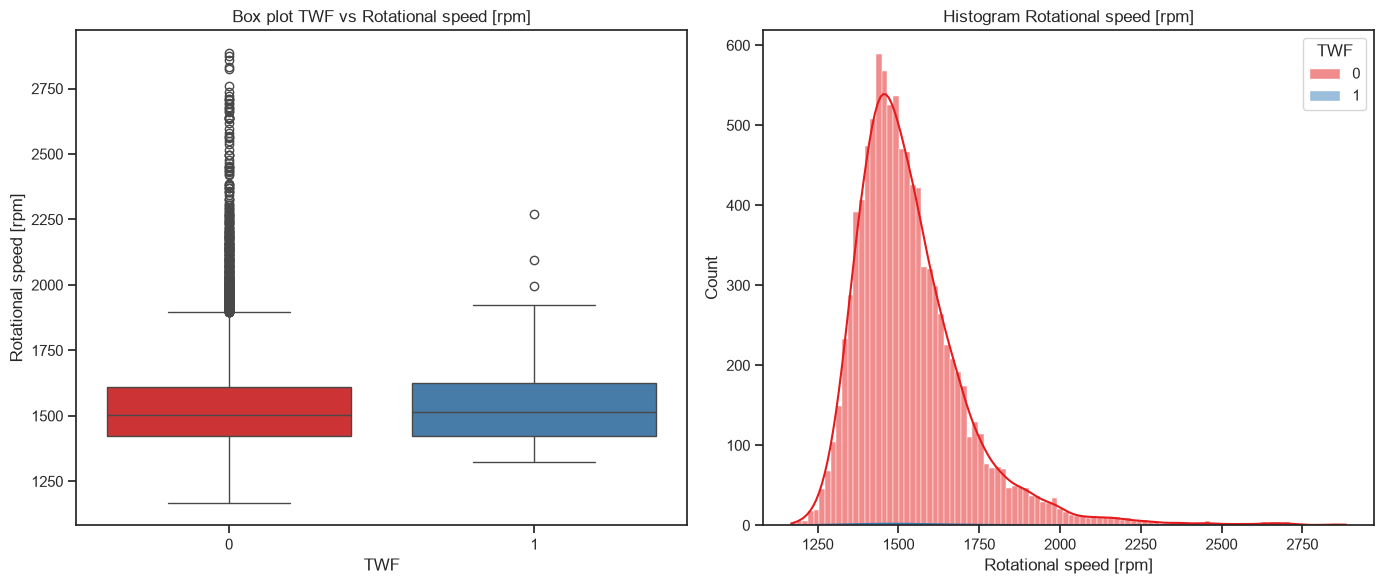

In [31]:
plot_box_hist(df, 'TWF', 'Rotational speed [rpm]')

Relationship between Torque and TWF

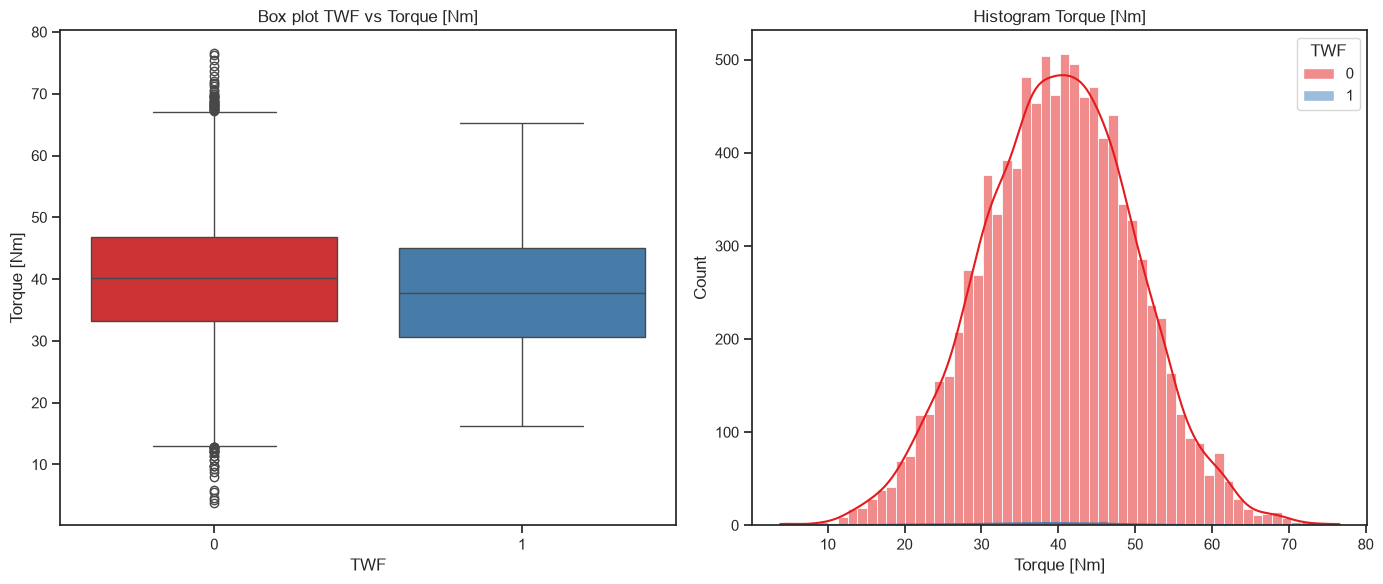

In [32]:
plot_box_hist(df, 'TWF', 'Torque [Nm]')

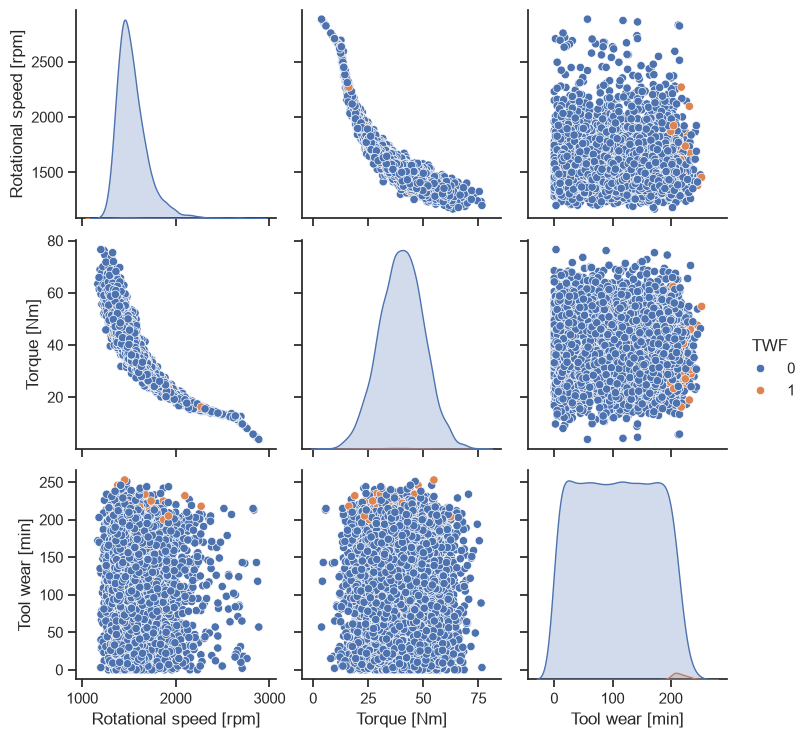

In [33]:
sns.pairplot(df[['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF']], hue='TWF')

#### HDF analysis

Relationship between temperature difference and HDF

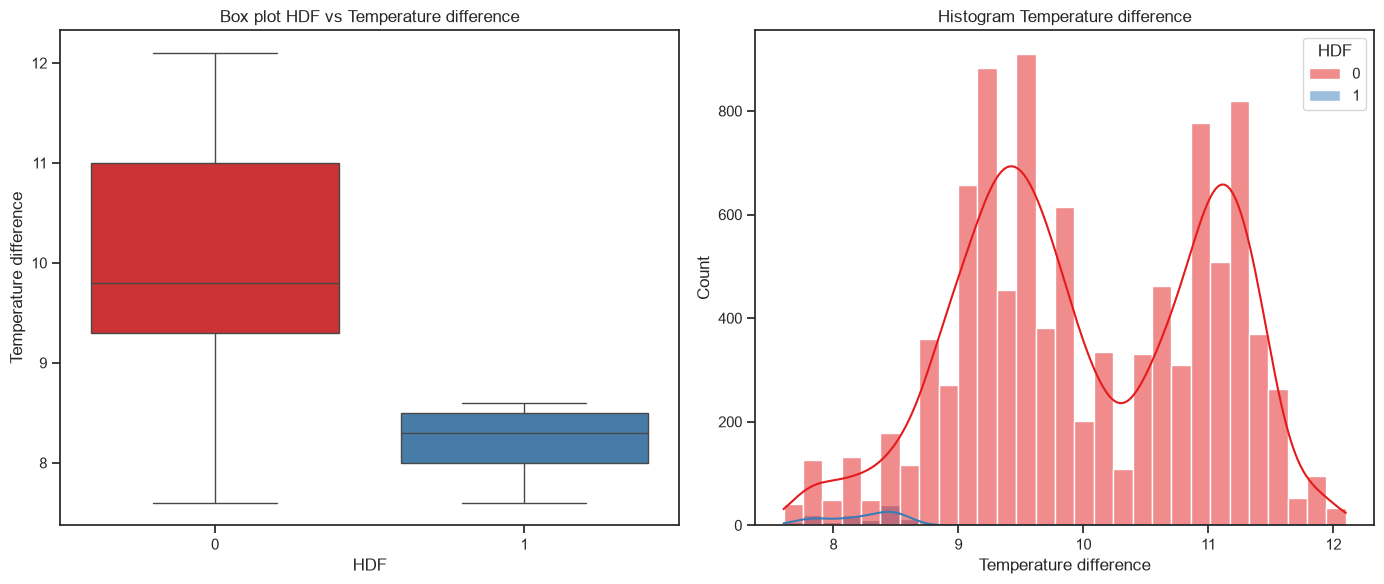

In [34]:
plot_box_hist(df, 'HDF', 'Temperature difference')

Range analysis

In [35]:
print(f"Lower bound: {df[df['HDF'] == 1]['Temperature difference'].agg('min').round(2)}")
print(f"Upper bound: {df[df['HDF'] == 1]['Temperature difference'].agg('max').round(2)}")

Lower bound: 7.6
Upper bound: 8.6


Relationship between Rotational speed and HDF

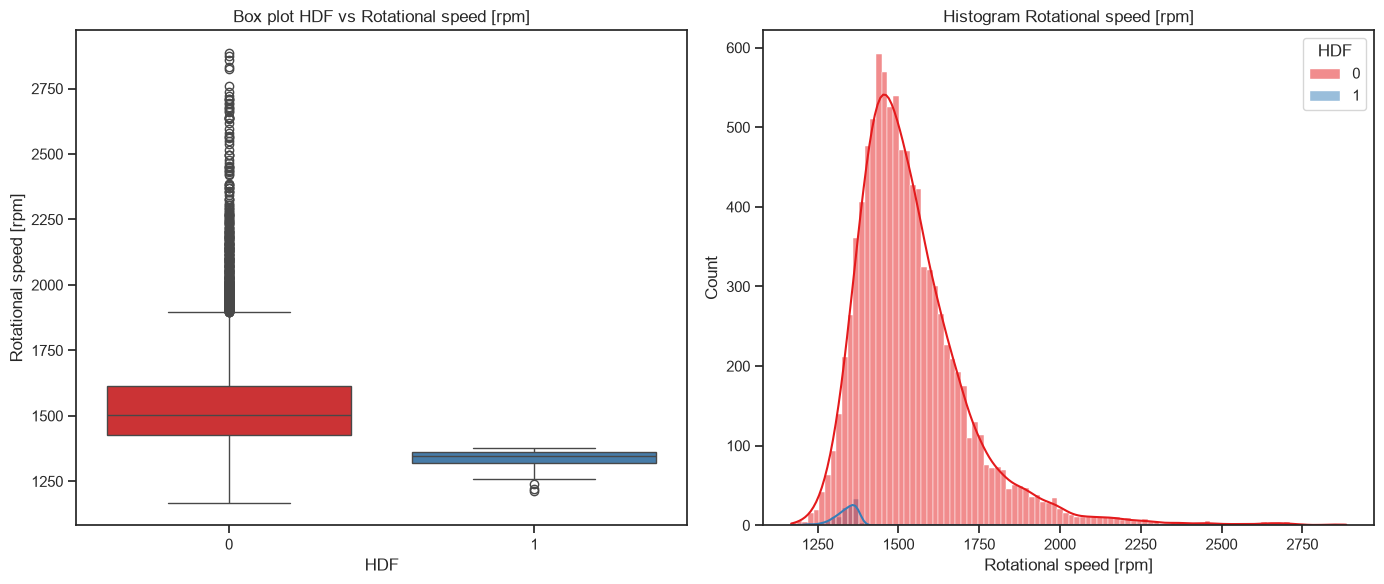

In [36]:
plot_box_hist(df, 'HDF', 'Rotational speed [rpm]')

Range analysis

In [37]:
print(f"Lower bound: {df[df['HDF'] == 1]['Rotational speed [rpm]'].agg('min').round(2)}")
print(f"Upper bound: {df[df['HDF'] == 1]['Rotational speed [rpm]'].agg('max').round(2)}")

Lower bound: 1212
Upper bound: 1379


Relationship between Power and PWF

#### PWF analysis

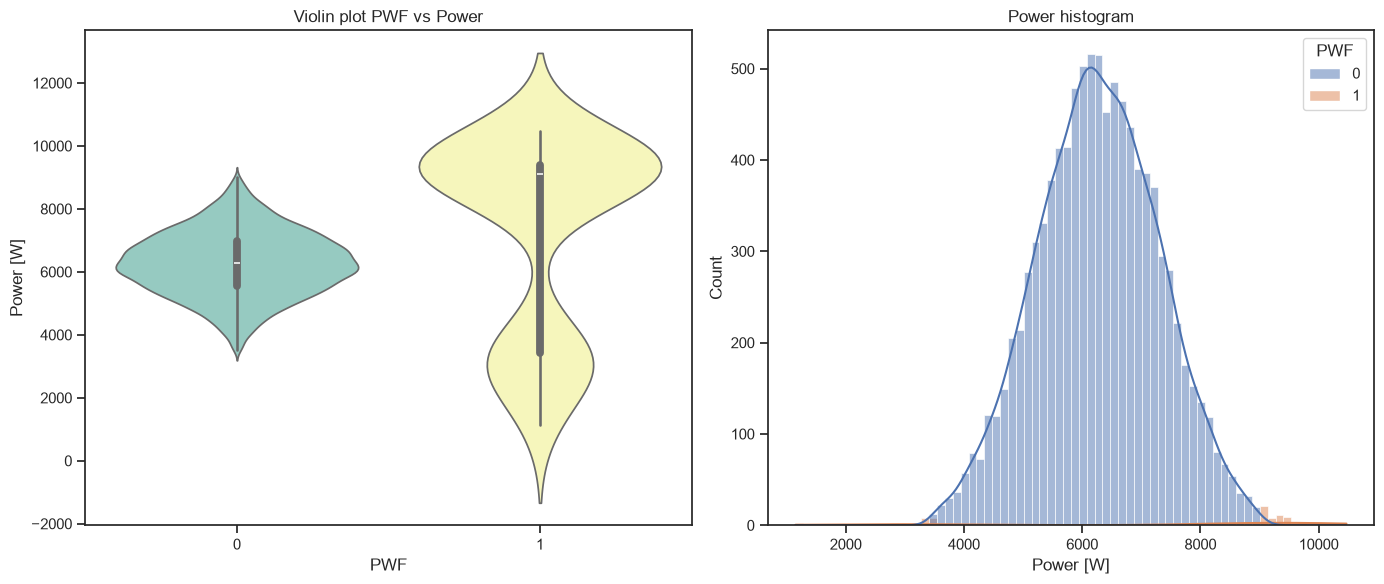

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(x="PWF", y="Power [W]", data=df, palette="Set3", ax=axes[0], hue ="PWF", legend=False)
axes[0].set_title("Violin plot PWF vs Power")

# Second plot goes on axes[1] (right-hand side)
sns.histplot(data=df, x="Power [W]", hue="PWF", kde=True, ax=axes[1])
axes[1].set_title("Power histogram")

plt.tight_layout()
plt.show()

Checking the split point

In [39]:
from sklearn.cluster import KMeans

# Prepare data (K-Means needs a 2D DataFrame, hence the double brackets)
X_pwf = df[df['PWF'] == 1][['Power [W]']]

# Build a K-Means model for 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
X_pwf['Peak'] = kmeans.fit_predict(X_pwf)

# Group by the detected peaks and extract min and max
pwf_ranges = X_pwf.groupby('Peak')['Power [W]'].agg(['min', 'max']).sort_values(by='min')

# Rename index labels to be more readable
pwf_ranges.index = ['Range 1', 'Range 2']
display(pwf_ranges.round(2))

,min,max
Range 1,1148.44,3477.24
Range 2,9004.43,10469.92


#### OSF analysis

Determining the threshold value

In [40]:
osf_criterion = df['Tool wear [min]'] * df['Torque [Nm]']
osf_threshold = osf_criterion[df['OSF'] == 1].min()
print(f"Estimated threshold value: about {osf_threshold}")

Estimated threshold value: about 11003.199999999999


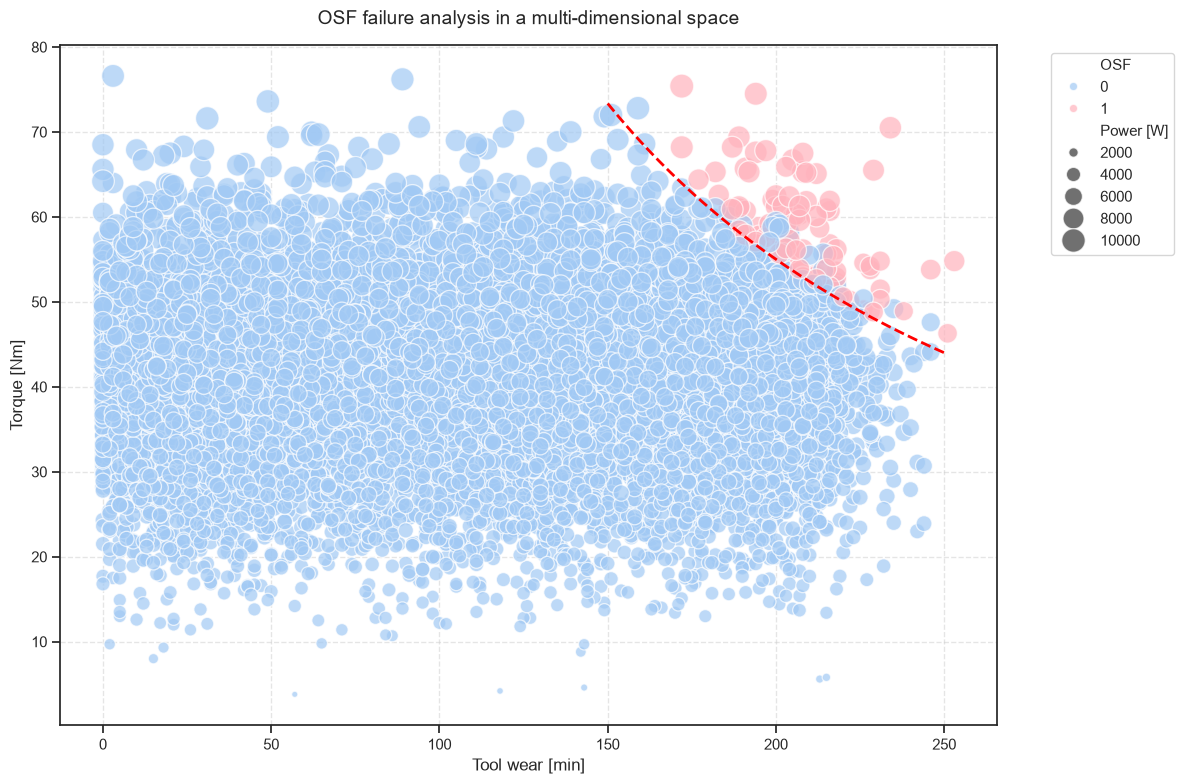

In [41]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='Tool wear [min]',
    y='Torque [Nm]',
    hue='OSF',
    size='Power [W]',
    sizes=(20, 300),
    alpha=0.7,
    palette={0: '#a1c9f4', 1: '#ffb3bd'}
)

plt.title('OSF failure analysis in a multi-dimensional space', fontsize=14, pad=15)
plt.xlabel('Tool wear [min]', fontsize=12)
plt.ylabel('Torque [Nm]', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

x_line = np.linspace(150, 250, 100)
y_line = osf_threshold / x_line

plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, label='Theoretical OSF boundary')
plt.tight_layout()
plt.show()